# Ft. Huachucah Methods
This is a review of the methods used to calculate biomass in the Ft. Huachucah area.

## Field Collection Methods



In [1]:
# import calc_biomass package
import sys
sys.path.append('../')
from calc_biomass import manage_data

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Jupyter magic to make plots display interactive
# must install ipympl (Ipython-matplotlib) and nodejs
from ipywidgets.embed import embed_minimal_html
%matplotlib widget

## Canopy Biomass Calculation Methods
### Calculating DRC from DBH
If a tree had a central stem, regardless of species, diameter was measured at DBH. But if the tree had multiple stems from a common root base, DRC (diameter at root collar was measured). Which measurement was used was recorded in the dataset. Most allometric equations require either DBH or DRC, so to be consistent within a species, the following equation was applied to the Excel spreadsheet to convert DBH to DRC for oak, pinyon, and juniper species.

    Chojnacky, D. 1988. Juniper, Pinyon, Oak, and Mesquite Volume Equations for Arizona. USDA Forest Service, Intermountain Research Station, Research Paper INT-RP-391. Ogden, UT.

### Calculating Equivalent DRC

Using standard protocol for Diameter at Root Collar (DRC), when multiple stems joined to a single root collar below the soil, individual stems were measured for the same tree. These multiple basal measurements must be combined into a single measurement using the equation:

equivalent diameter = $\sqrt{\sum_{i=1}^{n}RCD_{i}^{2}}$

This equation is provided in both of:
    
    Chojnakcy, D.C. 1992 . Estimating volume and biomass for dryland oak speices. In: Ffolliott P.F., Gottfried, G.J., Bennett, D.A., Hernandez, C.V.-M., Ortega-Rubio, A., and R.H. Hamre, technical coordinators. Ecology and management of oak and associated woodlands: perspectives in the southwestern United States and Northern Mexico. Proceedings April 7-30, 1992; Sierra Vista, AZ. USDA Forest Service, Rocky Mountain Forest and Range Experiment Station General Technical Report RM-218:155-161.
    
    Grier, C.C., Elliott, K.J., McCullough, D.G. 1992. Biomass distribution and productivity of Pinus edulis-Juniperus monosperma woodlands of north-central Arizona. Forest Ecology and Management, 50:331-350.

In [2]:
def calc_edrc(df):
    # df is one tree id from a single plot
    # for trees with only one tree id, the sqrt(d2) == d
    dbh = (sum(df['dbh']**2))**0.5
    
    other_val = df.max()

    newdf = pd.DataFrame()
    newdf.loc[1,'DBH'] = dbh
    newdf.loc[1, df.columns] = other_val

    return newdf

In [3]:
# load data
data = manage_data.LoadData()
data.load_data(data.data_path)

# calculate ERC
data.df.rename(columns={'Final DBH/DRC':'dbh', 'spp':'Species','Species Code':'spp'}, inplace=True)
data.df = data.df.groupby(['Plot', 'Tree Number']).apply(calc_edrc).reset_index()

In [4]:
# Error noted below, now the new df with it's new index needs to have units reassigned, but the column names are all changed around
data.units['input']['DBH'] = data.units['input'].pop('Final DBH/DRC')
data.check_df_units('input')

### Cleaning the data
A number of quality assurance procedures applied in the other Ft. Huachuca Jupyter notebooks identified the following data cleaning requirements.

In [5]:
# clean data

# missing species for generic pinyon
pied = data.df.spp.isna() & (data.df.Species=='Pinyon')
data.df.loc[pied, 'spp'] = 'PIED'

# height was calculated in Excel by applying Base reading and Top Reading to Distance (M)

# height Base reading for mesquite are in cm, not clinometer %
prve = (data.df['Height']<=0)&(data.df['Top Reading'].isna())#&(data.df['Base reading']>100)
data.df.loc[prve, 'Height'] = data.df.loc[prve, 'Base reading']/100

# height for acacia and creosote are in cm, not m
segr = (data.df['spp']=='SEGR10')&(data.df['Height'].pint.magnitude>=100)&(data.df['Top Reading'].isna())
data.df.loc[segr, 'Height'] = data.df.loc[segr, 'Height']/100

# height for creosote are in cm, not m
latr = (data.df['spp']=='LATR2')&(data.df['Height'].pint.magnitude>=100)&(data.df['Top Reading'].isna())
data.df.loc[latr, 'Height'] = data.df.loc[latr, 'Height']/100

# accidentally flipped the sign of a juniper height clinometer %
jude = (data.df['spp']=='JUDE2')&(data.df['Height']<0)
ht = (-data.df.loc[jude, 'Top Reading']- data.df.loc[jude, 'Base reading']) / 100 * data.df.loc[jude, 'Distance (M)']
data.df.loc[jude, 'Height'] = ht

# quarter inch drc tree 2 cm circumference (actual circumference 200 cm)
qrt_in = (data.df['spp']=='QUEM')&(data.df['DBH'].pint.magnitude<1)
c = 200
d = c/np.pi
d_in = d/2.54
data.df.loc[qrt_in, 'DBH'] = d_in
data.df.loc[qrt_in, 'DBH/DRC Circumfrence (cm)'] = 200

# 3m DRC (circumference 94, not 944)
m3 = (data.df['spp']=='QUOB')&(data.df['DBH'].pint.magnitude>117)
c = 94
dbh_cm = c / np.pi
dbh_in = dbh_cm / 2.54
data.df.loc[m3, 'DBH'] = dbh_in
data.df.loc[m3, 'DBH/DRC Circumfrence (cm)'] = c

# cbh cleaning- if there is no clino reading, replace with nan. Mostly impacts dead trees
# Excel equation was still calculating a CBH off of the tree base reading
no_cbh = data.df['Lowest Canopy Height Reading'].isna()
data.df.loc[no_cbh, 'Lowest Canopy Height'] = np.nan

# CBH for some mesquite trees was measured in cm, not clino %. These are the same trees where height was recorded in cm in Base reading
no_clino = (data.df['Lowest Canopy Height'].pint.magnitude<=0)&(data.df['Base reading'] >=100)&(data.df['Top Reading'].isna())
data.df.loc[no_clino, 'Lowest Canopy Height'] = data.df.loc[no_clino, 'Lowest Canopy Height Reading']/100

# Flip the signs on the two remaining - CBH
cbh_below_grd = (data.df['Base reading'] > data.df['Lowest Canopy Height Reading']) & (data.df['Lowest Canopy Height'].pint.magnitude<0) 
neg_cbh = cbh_below_grd & (data.df['spp']=='JUDE2')
# flip the sign of the cbh reading
cbh = (-data.df.loc[neg_cbh, 'Lowest Canopy Height Reading']- data.df.loc[neg_cbh, 'Base reading']) / 100 * data.df.loc[neg_cbh, 'Distance (M)']
data.df.loc[neg_cbh, 'Lowest Canopy Height'] = cbh

neg_cbh = cbh_below_grd & (data.df['spp']=='PRVE')
# flip the sign of the base reading
grd = (-data.df.loc[neg_cbh, 'Base reading'])
cbh = (data.df.loc[neg_cbh, 'Lowest Canopy Height Reading']- grd ) / 100 * data.df.loc[neg_cbh, 'Distance (M)']
ht = (data.df.loc[neg_cbh, 'Top Reading']- grd ) / 100 * data.df.loc[neg_cbh, 'Distance (M)']
data.df.loc[neg_cbh, 'Lowest Canopy Height'] = cbh
data.df.loc[neg_cbh, 'Height'] = ht

### Calculating biomass

Biomass is calculated in up to 3 categories:

* Total biomass- includes tree boles, foliage, and all branches
* Foliar biomass
* Available canopy fuel- this is defined as foliage + 0.5 * (0-6mm branches)

Available canopy fuel is defined in:

    Scott, J., Reinhardt, E. 2001. Assessing crown fire potential by linking models of surface and crown fire behavior. USDA, Forest Service, Rocky Mountain Research Station, Res. Pap. RMRS-RP-29

    Brown, J.K., Reinhardt, E. D. 1991. Predicting and managing fuel consumption in the interior west. In: Andrews, P., Potts, D., eds. Proceedings of the 11th conference on fire and forest meteorology. Proceedings April 16-19, 1991; Missoula, MT. Society of American Foresters. 

#### Allometric equations

##### Oaks
This was developed for oak species found througought Arizona and New Mexico, with the primary differentiation between species being wood density (Emory vs. Gambell). The equation uses a small branchwood size class of 0-50mm, which is larger than the 1 hour fuel class, which is 0-6mm. This will cause it to over-estimate available canopy fuel.

This equations derives foliage and small branchwood from total stem volume. In rare cases (1 in our dataset), if the equation is used with drc's below 7 cm and heights below 2 m it can produce negative volume. In these cases, the stemwood volume is then recalculated as the volume of cylinder.

    Chojnakcy, D.C. 1992 . Estimating volume and biomass for dryland oak speices. In: Ffolliott P.F., Gottfried, G.J., Bennett, D.A., Hernandez, C.V.-M., Ortega-Rubio, A., and R.H. Hamre, technical coordinators. Ecology and management of oak and associated woodlands: perspectives in the southwestern United States and Northern Mexico. Proceedings April 7-30, 1992; Sierra Vista, AZ. USDA Forest Service, Rocky Mountain Forest and Range Experiment Station General Technical Report RM-218:155-161.

##### Pinyon and Juniper
This equation was developed from a small set of trees outside of Flagstaff, AZ and only includes equations for one species of pinyon and one of juniper. The equation uses a small branchwood size class of 0-25 mm, which is larger than the 1 hour fuel class, which is 0-6 mm. To adjust for this over-estimation, adjustment factors from FuelCalc are used.

    Grier, C.C., Elliott, K.J., McCullough, D.G. 1992. Biomass distribution and productivity of Pinus edulis-Juniperus monosperma woodlands of north-central Arizona. Forest Ecology and Management, 50:331-350.

1 hour fuels use branchwood adjustment factor from FuelCalc:

    Lutes, D. 2020. FuelCalc User's Guide (version 1.7). USDA Forest Service, Rocky Mountain Research Station.

##### Ponderosa Pines

Equations were developed for British Columbia and require tree volume from the BC Ministry of Forestry volume tables.

In rare cases (1 in our dataset) where trees are dead with a broken top, leaving a short, thick cylinder, the volume equations underestimate the volume of the tree enough to unbalance the equation and produce negative biomass. In these cases, the volume is recalculated as a cylinder.

    Standish, J.T., Manning, G.H., and Demaerschalk, J.P. 1985. Development of biomass equations for British Columbia tree species. Canadian Forestry Service, Pacific Forest Research Centre, Information Report BC-X-264 (Vancouver, BC)

    Susan Watts eds. 1983. Forestry Handbook for British Columbia, 4th Edition. University of British Columbia. Forest Club. pp 431-434.

##### Chihuahua and Southwestern White Pines

These equations were developed for northern Mexico pine and oak forests. They do not define branchwood size, so branchwood is excluded from available canopy fuel. This will cause the equation to under-estimate available canopy fuel. 

    Vargas-Larreta, B., Lopez-Sanches, C.A., Corral-Rivas, J.J., Lopez-Martinez, J.O., Aguierre-Calderon, C.G., and Alvarez-Gonzalez, J.G. 2017. Allometric equations for estimating biomass adn carbon stocks in the temperate forests of north-western Mexico. Forests 2017; 8(8): 269. https://doi.org/10.3390/f8080269

##### Mesquite
This equation was developed for southern Arizona. Results fall within the low end of the range of other studies. The equation uses a small branchwood size class of 0-10mm, which is larger than the 1 hour fuel class, which is 0-6mm. This will cause it to over-estimate available canopy fuel.

    McClaran, M.P., McMurtry, C.R., Archer, S.R. 2013. A tool for estimating impacts of woody encroachment in arid grasslands: Allometric equations for biomass, carbon and nitrogen content in Posopis veluntina. Journal of Arid Environnments 88(2013): 39-12
    

In [6]:
wt = manage_data.CalcBiomass(data)
# what equations should be used for these species?
wt.add_equ_column()

In [7]:
wt.calc_biomass('total')

In [8]:
wt.calc_biomass('foliage')

In [9]:
wt.calc_biomass('avl_canfuel')

### Graphing the distribution by trees
A quick look at the distribution of biomasses per tree.

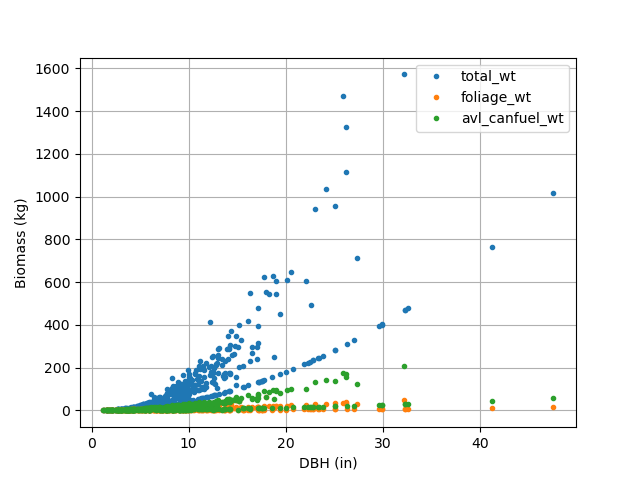

In [10]:
df = wt.ldata.df.pint.dequantify().droplevel(level=1, axis=1)
df = df[['DBH', 'Height','total_wt', 'foliage_wt', 'avl_canfuel_wt']].dropna()
plt.figure()
plt.plot(df['DBH'], df[['total_wt', 'foliage_wt', 'avl_canfuel_wt']], linestyle='', marker='.')

plt.legend(['total_wt', 'foliage_wt', 'avl_canfuel_wt'])
plt.xlabel('DBH (in)')
plt.ylabel('Biomass (kg)')
plt.grid('on')

Text(0, 0.5, 'Biomass (kg)')

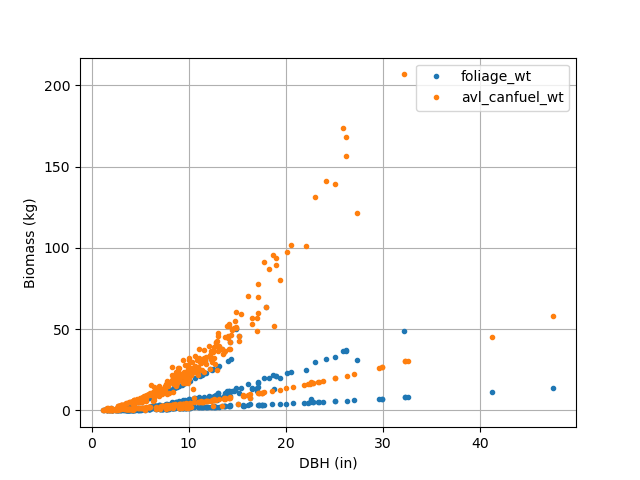

In [12]:
plt.figure()
plt.plot(df['DBH'], df[['foliage_wt', 'avl_canfuel_wt']], linestyle='', marker='.')

plt.legend(['foliage_wt', 'avl_canfuel_wt'])
plt.grid('on')
plt.xlabel('DBH (in)')
plt.ylabel('Biomass (kg)')

Text(0, 0.5, 'Biomass (kg)')

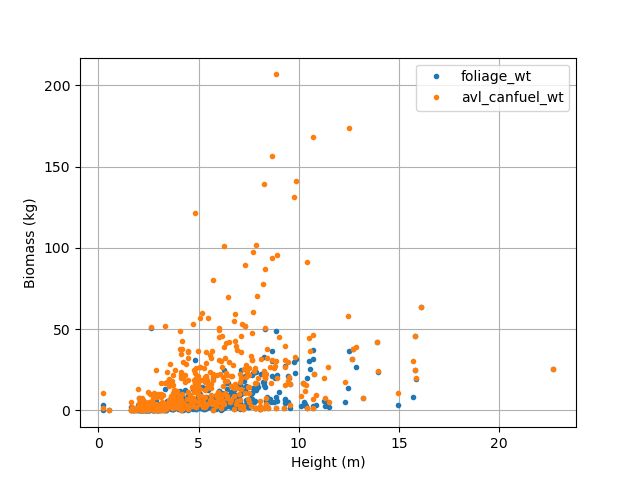

In [13]:
plt.figure()
plt.plot(df['Height'], df[['foliage_wt', 'avl_canfuel_wt']], linestyle='', marker='.')

plt.legend(['foliage_wt', 'avl_canfuel_wt'])
plt.grid('on')
plt.xlabel('Height (m)')
plt.ylabel('Biomass (kg)')

Text(0, 0.5, 'Height (m)')

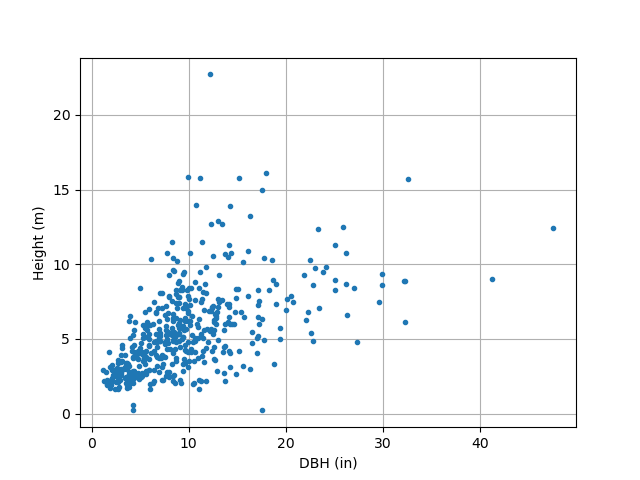

In [14]:
plt.figure()
plt.plot(df['DBH'], df['Height'], linestyle='', marker='.')

plt.grid('on')
plt.xlabel('DBH (in)')
plt.ylabel('Height (m)')

## Reducing biomass of dead trees
Dead trees should have some reduction in biomass. Talking over the field protocols with Zito, he made a clear distinction in the field between trees with foliage (red and dead or green; class 2) and trees with 0-15% of their foliage remaining (class 3). Put another way, many or most of the class 3 trees had no foliage left, but none of them had more than 15% remaining. So the decision is to remove all foliar biomass. We will leave the branchwood and bark, and assume that "candlestick" snags where all branches and bark have sloughed off are rare.

In [15]:
dead = wt.ldata.df['Tree Condition'] == 3

wt.ldata.df.loc[dead, 'total_wt'] -= wt.ldata.df.loc[dead, 'foliage_wt']
wt.ldata.df.loc[dead, 'avl_canfuel_wt'] -= wt.ldata.df.loc[dead, 'foliage_wt']
wt.ldata.df.loc[dead, 'foliage_wt'] = 0

## Summarizing by plot
For each plot, get the total amount of fuel, and summarize by plot size.

In [43]:
from pint import UnitRegistry
import pint_pandas

ureg = UnitRegistry()
pint_pandas.PintType.ureg = ureg

In [51]:
new_df = pd.DataFrame(index=wt.ldata.df['Plot'].unique(), dtype='float')

fuel_col =  ['total_wt', 'avl_canfuel_wt', 'foliage_wt']
ht_col = ['Height', 'Lowest Canopy Height']
plt_size = np.pi * (10*ureg.m)**2

wt.ldata.df['BA'] = np.pi*(wt.ldata.df['DBH']/2)**2

for plot, pdf in wt.ldata.df.groupby('Plot'):
    
    new_df.loc[plot, fuel_col] = pdf[fuel_col].sum() / plt_size
    new_df.loc[plot, ht_col] = pdf[ht_col].mean()
   
    mean_ba = pdf['BA'].mean()
    new_df.loc[plot, 'QMD'] = (2*(mean_ba/np.pi)**0.5).to('cm')

    spp_ba = pdf.groupby('Species')['BA'].agg('sum')
    new_df.loc[plot, 'Dominant_Species'] = spp_ba.idxmax()
    new_df.loc[plot, 'Dominant_Species_BA_percent'] = spp_ba.max()/spp_ba.sum() * 100 * ureg.percent

In [52]:
#unfortunately, the pint units get a little squirrely here and are attached to the value, not the column array as a datatype
for col in new_df.columns:
    n = new_df[col].iloc[0]
    if hasattr(n, 'units'):
        unit = n.units
        new_df[col] = new_df[col].astype(f"pint[{unit}]")

In [53]:
new_df.dtypes

total_wt                       pint[kilogram / meter ** 2][Float64]
avl_canfuel_wt                 pint[kilogram / meter ** 2][Float64]
foliage_wt                     pint[kilogram / meter ** 2][Float64]
Height                                         pint[meter][Float64]
Lowest Canopy Height                           pint[meter][Float64]
QMD                                       pint[centimeter][Float64]
Dominant_Species                                                str
Dominant_Species_BA_percent                  pint[percent][Float64]
dtype: object

In [54]:
new_df.pint.dequantify().describe()

,total_wt,avl_canfuel_wt,foliage_wt,Height,Lowest Canopy Height,QMD,Dominant_Species_BA_percent
unit,kilogram / meter ** 2,kilogram / meter ** 2,kilogram / meter ** 2,meter,meter,centimeter,percent
count,52.0,52.0,52.0,51.0,50.0,52.0,52.0
mean,3.631882,0.501921,0.160025,5.591169,2.048638,31.045168,78.160012
std,3.445241,0.501895,0.181494,2.808203,1.432584,15.007618,23.817578
min,0.0,0.0,0.0,1.9,0.304,2.864789,35.372219
25%,0.938484,0.069133,0.018887,3.4185,0.98,20.830614,54.433596
50%,2.910809,0.344115,0.085713,5.370711,1.6725,28.874678,88.375851
75%,4.860431,0.739314,0.24304,6.777167,2.766224,38.032131,100.0
max,13.682691,1.617836,0.801879,17.792231,6.5602,66.526766,100.0


In [55]:
new_df.pint.dequantify()

,total_wt,avl_canfuel_wt,foliage_wt,Height,Lowest Canopy Height,QMD,Dominant_Species,Dominant_Species_BA_percent
unit,kilogram / meter ** 2,kilogram / meter ** 2,kilogram / meter ** 2,meter,meter,centimeter,No Unit,percent
101,4.474765,0.364827,0.220578,11.495625,6.180286,45.104484,Alligator Juniper,78.301813
105,10.946958,1.156212,0.512496,8.968182,5.0604,53.671134,Alligator Juniper,77.083034
167,4.578615,0.52446,0.138669,6.079086,2.769443,29.358348,Alligator Juniper,60.167441
307,12.188818,1.219176,0.317203,7.134513,3.45165,44.839418,Alligator Juniper,54.701877
308,2.332778,0.074764,0.037169,7.510183,3.71035,31.810292,Alligator Juniper,55.278529
358,7.293706,1.449937,0.599158,4.715333,2.155243,19.349648,Mexican Blue Oak,46.780708
411,2.228411,0.383969,0.095883,5.04,1.62,34.455167,Emory Oak,53.294793
462,5.256338,0.755818,0.191576,6.42,1.74,54.252307,Alligator Juniper,52.473714
513,3.567203,0.480578,0.244341,6.654333,2.430083,38.491893,Alligator Juniper,63.494459


In [56]:
data.export_csv(df=new_df)